In [1]:
from pathlib import Path
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import mplhep as hep
from matplotlib import colors
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from functools import reduce
import inspect
from tqdm import tqdm

from boostedhh import utils, hh_vars

In [2]:
# automatically reloads imported files on edits
%load_ext autoreload
%autoreload 2

def print_directory_tree(base_dir, indent=""):
    for root, dirs, files in os.walk(base_dir):
        level = root.replace(base_dir, "").count(os.sep)
        indent = " " * 4 * level
        print(f"{indent}|-- {os.path.basename(root)}/")
        sub_indent = " " * 4 * (level + 1)
        for file in files:
            print(f"{sub_indent}|-- {file}")

In [3]:
MAIN_DIR = Path("../../../")

plot_dir = MAIN_DIR / "plots/TriggerStudy/24Nov9"
plot_dir.mkdir(parents=True, exist_ok=True)

samples_tag = "25Feb7NoFatJetSel_v12_private_signal"
# samples_tag = "24Nov9UpdateTriggers_v12_private_signal"
base_dir = f"/eos/uscms/store/user/rkansal/bbtautau/skimmer/{samples_tag}/2022/"
# print_directory_tree(base_dir)

df = pd.read_parquet(
    base_dir + "GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_LHEweights_TuneCP5_13p6TeV_powheg-pythia8/parquet/"
)    

cf = utils.get_cutflow(
    base_dir + "GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_LHEweights_TuneCP5_13p6TeV_powheg-pythia8/pickles",
    "2022",
    "GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_LHEweights_TuneCP5_13p6TeV_powheg-pythia8",
)

In [4]:
list(df.keys())

[('GenHiggsEta', 0),
 ('GenHiggsEta', 1),
 ('GenHiggsPhi', 0),
 ('GenHiggsPhi', 1),
 ('GenHiggsMass', 0),
 ('GenHiggsMass', 1),
 ('GenHiggsPt', 0),
 ('GenHiggsPt', 1),
 ('GenHiggsChildren', 0),
 ('GenHiggsChildren', 1),
 ('GenbbEta', 0),
 ('GenbbEta', 1),
 ('GenbbPhi', 0),
 ('GenbbPhi', 1),
 ('GenbbMass', 0),
 ('GenbbMass', 1),
 ('GenbbPt', 0),
 ('GenbbPt', 1),
 ('GenTauEta', 0),
 ('GenTauEta', 1),
 ('GenTauPhi', 0),
 ('GenTauPhi', 1),
 ('GenTauMass', 0),
 ('GenTauMass', 1),
 ('GenTauPt', 0),
 ('GenTauPt', 1),
 ('GenTauhh', 0),
 ('GenTauhmu', 0),
 ('GenTauhe', 0),
 ('run', 0),
 ('event', 0),
 ('luminosityBlock', 0),
 ('MET_pt', 0),
 ('ht', 0),
 ('nJets', 0),
 ('nFatJets', 0),
 ('nPU', 0),
 ('nPV', 0),
 ('HLT_AK8PFJet425_SoftDropMass40', 0),
 ('HLT_AK8PFJet250_SoftDropMass40_PFAK8ParticleNetBB0p35', 0),
 ('HLT_AK8PFJet230_SoftDropMass40_PFAK8ParticleNetTauTau0p30', 0),
 ('HLT_QuadPFJet70_50_40_35_PFBTagParticleNet_2BTagSum0p65', 0),
 ('HLT_LooseDeepTauPFTauHPS180_L2NN_eta2p1', 0),
 ('HL

In [5]:
acc_cond = {
    'eta_tau': 2.5, 'pt_tau': 20, 
    'eta_bb': 2.5, 'pt_bb': 40,
    'eta_ak4': 2.5, 'pt_ak4': 20,
    'eta_ak8': 2.5, 'pt_ak8': 200
    }

acc_mask_tau = (
    (df[('GenTauPt',  0)] > acc_cond['pt_tau'])  &
    (np.abs(df[('GenTauEta', 0)]) < acc_cond['eta_tau']) &
    (df[('GenTauPt',  1)] > acc_cond['pt_tau'])  &
    (np.abs(df[('GenTauEta', 1)]) < acc_cond['eta_tau'])
)

acc_mask_bb = (
    (df[('GenbbPt',   0)] > acc_cond['pt_bb'])   &
    (np.abs(df[('GenbbEta', 0)]) < acc_cond['eta_bb']) &
    (df[('GenbbPt',   1)] > acc_cond['pt_bb'])   &
    (np.abs(df[('GenbbEta', 1)]) < acc_cond['eta_bb'])
)

# AK4 jets: require AT LEAST ONE jet to pass the cuts 
ak4_pt_cols  = [('ak4JetPt',  i)  for i in range(4)]
ak4_eta_cols = [('ak4JetEta', i)  for i in range(4)]
acc_mask_ak4 = (
    df[ak4_pt_cols].gt(acc_cond['pt_ak4']).any(axis=1)  &
    df[ak4_eta_cols].abs().lt(acc_cond['eta_ak4']).any(axis=1)
)

# AK8 fatjets: require AT LEAST ONE to pass 
ak8_pt_cols  = [('ak8FatJetPt',  i) for i in range(3)]
ak8_eta_cols = [('ak8FatJetEta', i) for i in range(3)]
acc_mask_ak8 = (
    df[ak8_pt_cols].gt(acc_cond['pt_ak8']).any(axis=1)  &
    df[ak8_eta_cols].abs().lt(acc_cond['eta_ak8']).any(axis=1)
)

# Global event mask & filtered dataframe 
acc_mask_total = acc_mask_tau & acc_mask_bb #& acc_mask_ak4 & acc_mask_ak8
df_acc     = df[acc_mask_total].copy()    


In [6]:
N = df[("weight", 0)].sum()
N_A = df_acc[("weight", 0)].sum()
eps_A = N_A / N
print(f'N: {N:.6f}')
print(f'N (acc): {N_A:.6f}')
print(f'Eps (acc): {eps_A:.6f}')

N: 479625.890318
N (acc): 208133.281737
Eps (acc): 0.433949


In [7]:
def delta_r(eta1, phi1, eta2, phi2):
    """Delta_R with stable, wrapped Delta_phi."""
    d_phi = np.mod(phi1 - phi2 + np.pi, 2*np.pi) - np.pi # making \phi \in [-pi, +pi]
    d_eta = eta1 - eta2
    d_R = np.hypot(d_eta, d_phi)
    return d_R

In [8]:
def gen_categorization(df, deltaR_threshold=0.8):
    weights = df["weight"][0]

    deltaR_bb = delta_r(df[('GenbbEta', 0)], df[('GenbbPhi', 0)], df[('GenbbEta', 1)], df[('GenbbPhi', 1)])
    deltaR_tau = delta_r(df[('GenTauEta', 0)], df[('GenTauPhi', 0)], df[('GenTauEta', 1)], df[('GenTauPhi', 1)])

    bb_boosted = deltaR_bb < deltaR_threshold
    tau_boosted = deltaR_tau < deltaR_threshold

    bb_resolved = ~bb_boosted
    tau_resolved = ~tau_boosted

    return weights, bb_boosted, bb_resolved, tau_boosted, tau_resolved

100%|██████████| 360/360 [00:26<00:00, 13.84it/s]


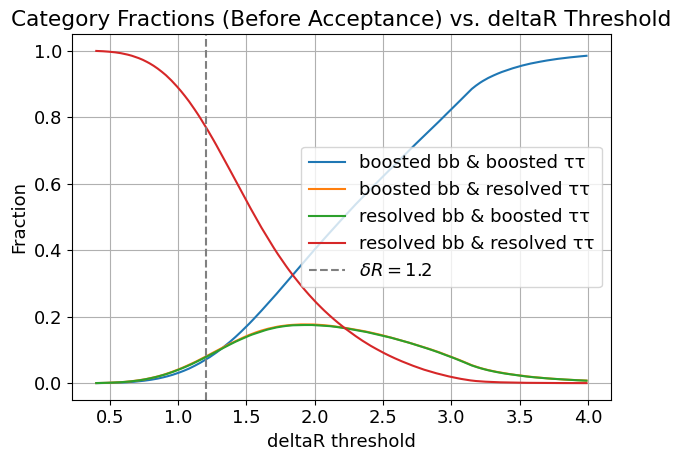

In [120]:
delta_R_th_range = np.arange(0.4, 4.0, 0.01)

bb_boosted_tau_boosted = []
bb_boosted_tau_resolved = []
bb_resolved_tau_boosted = []
bb_resolved_tau_resolved = []

for deltaR_th in tqdm(delta_R_th_range):
    weights, bb_boosted, bb_resolved, tau_boosted, tau_resolved = \
        gen_categorization(df, deltaR_threshold=deltaR_th)
    total_weight = weights.sum()
    bb_boosted_tau_boosted.append((weights[bb_boosted & tau_boosted].sum()) / total_weight)
    bb_boosted_tau_resolved.append((weights[bb_boosted & tau_resolved].sum()) / total_weight)
    bb_resolved_tau_boosted.append((weights[bb_resolved & tau_boosted].sum()) / total_weight)
    bb_resolved_tau_resolved.append((weights[bb_resolved & tau_resolved].sum()) / total_weight)

plt.plot(delta_R_th_range, bb_boosted_tau_boosted, label='boosted bb & boosted ττ')
plt.plot(delta_R_th_range, bb_boosted_tau_resolved, label='boosted bb & resolved ττ')
plt.plot(delta_R_th_range, bb_resolved_tau_boosted, label='resolved bb & boosted ττ')
plt.plot(delta_R_th_range, bb_resolved_tau_resolved, label='resolved bb & resolved ττ')

plt.axvline(x=1.2, linestyle='--', color='gray', label=r'$\delta R = 1.2$')


plt.xlabel("deltaR threshold")
plt.ylabel("Fraction")
plt.title("Category Fractions (Before Acceptance) vs. deltaR Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


  5%|▍         | 17/360 [00:00<00:08, 39.81it/s]

100%|██████████| 360/360 [00:11<00:00, 31.55it/s]


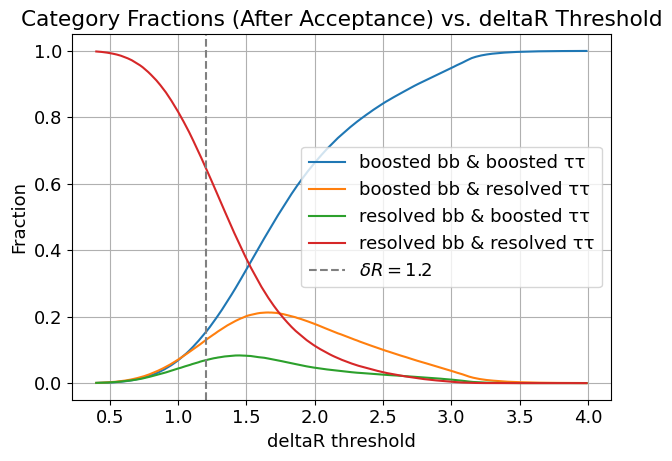

In [121]:
delta_R_th_range = np.arange(0.4, 4.0, 0.01)

bb_boosted_tau_boosted = []
bb_boosted_tau_resolved = []
bb_resolved_tau_boosted = []
bb_resolved_tau_resolved = []

for deltaR_th in tqdm(delta_R_th_range):
    weights, bb_boosted, bb_resolved, tau_boosted, tau_resolved = \
        gen_categorization(df_acc, deltaR_threshold=deltaR_th)
    total_weight = weights.sum()
    bb_boosted_tau_boosted.append((weights[bb_boosted & tau_boosted].sum()) / total_weight)
    bb_boosted_tau_resolved.append((weights[bb_boosted & tau_resolved].sum()) / total_weight)
    bb_resolved_tau_boosted.append((weights[bb_resolved & tau_boosted].sum()) / total_weight)
    bb_resolved_tau_resolved.append((weights[bb_resolved & tau_resolved].sum()) / total_weight)

plt.plot(delta_R_th_range, bb_boosted_tau_boosted, label='boosted bb & boosted ττ')
plt.plot(delta_R_th_range, bb_boosted_tau_resolved, label='boosted bb & resolved ττ')
plt.plot(delta_R_th_range, bb_resolved_tau_boosted, label='resolved bb & boosted ττ')
plt.plot(delta_R_th_range, bb_resolved_tau_resolved, label='resolved bb & resolved ττ')

plt.axvline(x=1.2, linestyle='--', color='gray', label=r'$\delta R = 1.2$')

plt.xlabel("deltaR threshold")
plt.ylabel("Fraction")
plt.title("Category Fractions (After Acceptance) vs. deltaR Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [9]:
weights, bb_boosted, bb_resolved, tau_boosted, tau_resolved = gen_categorization(df, deltaR_threshold=1.2)

# print(f'boosted bb (fraction): {weights[bb_boosted].sum() / weights.sum():.6f}')
# print(f'resolved bb (fraction): {weights[bb_resolved].sum() / weights.sum():.6f}')
# print(f'boosted ττ (fraction): {weights[tau_boosted].sum() / weights.sum():.6f}')
# print(f'resolved ττ (fraction): {weights[tau_resolved].sum() / weights.sum():.6f}')

# print()

print(f'boosted bb & boosted ττ (fraction): {weights[bb_boosted & tau_boosted].sum() / weights.sum():.6f}')
print(f'boosted bb & resolved ττ (fraction): {weights[bb_boosted & tau_resolved].sum() / weights.sum():.6f}')
print(f'resolved bb & boosted ττ (fraction): {weights[bb_resolved & tau_boosted].sum() / weights.sum():.6f}')
print(f'resolved bb & resolved ττ (fraction): {weights[bb_resolved & tau_resolved].sum() / weights.sum():.6f}')

print('='*50)
print('Acceptance Cuts')
print('='*50)

weights, bb_boosted, bb_resolved, tau_boosted, tau_resolved = gen_categorization(df_acc, deltaR_threshold=1.2)

# print(f'boosted bb (fraction): {weights[bb_boosted].sum() / weights.sum():.6f}')
# print(f'resolved bb (fraction): {weights[bb_resolved].sum() / weights.sum():.6f}')
# print(f'boosted ττ (fraction): {weights[tau_boosted].sum() / weights.sum():.6f}')
# print(f'resolved ττ (fraction): {weights[tau_resolved].sum() / weights.sum():.6f}')

# print()

print(f'boosted bb & boosted ττ (fraction): {weights[bb_boosted & tau_boosted].sum() / weights.sum():.6f}')
print(f'boosted bb & resolved ττ (fraction): {weights[bb_boosted & tau_resolved].sum() / weights.sum():.6f}')
print(f'resolved bb & boosted ττ (fraction): {weights[bb_resolved & tau_boosted].sum() / weights.sum():.6f}')
print(f'resolved bb & resolved ττ (fraction): {weights[bb_resolved & tau_resolved].sum() / weights.sum():.6f}')

boosted bb & boosted ττ (fraction): 0.070304
boosted bb & resolved ττ (fraction): 0.079799
resolved bb & boosted ττ (fraction): 0.078028
resolved bb & resolved ττ (fraction): 0.771868
Acceptance Cuts
boosted bb & boosted ττ (fraction): 0.152236
boosted bb & resolved ττ (fraction): 0.129083
resolved bb & boosted ττ (fraction): 0.068789
resolved bb & resolved ττ (fraction): 0.649892


In [10]:

# Check the vector library

# pull the columns out in numpy (way easier!!)
# TODO: Clean it up later with just pd implemenation 

df_check = df_acc

is_both_tau_had = df_check[('GenTauhh', 0)]

# Three AK8 jets
ak8_eta = np.vstack([df_check[('ak8FatJetEta', i)].to_numpy()
                     for i in (0,1,2)]).T       # shape (N,3)
ak8_phi = np.vstack([df_check[('ak8FatJetPhi', i)].to_numpy()
                     for i in (0,1,2)]).T
ak8_pt  = np.vstack([df_check[('ak8FatJetPt',  i)].to_numpy()
                     for i in (0,1,2)]).T

# Four AK4 jets
ak4_eta = np.vstack([df_check[('ak4JetEta',    i)].to_numpy()
                     for i in (0,1,2,3)]).T     # shape (N,4)
ak4_phi = np.vstack([df_check[('ak4JetPhi',    i)].to_numpy()
                     for i in (0,1,2,3)]).T
ak4_pt  = np.vstack([df_check[('ak4JetPt',     i)].to_numpy()
                     for i in (0,1,2,3)]).T

# replace NaNs (empty jet slots) with random values so they never match
ak8_eta  = np.nan_to_num(ak8_eta,  nan= 99.)
ak8_phi  = np.nan_to_num(ak8_phi,  nan= 99.)
ak8_pt   = np.nan_to_num(ak8_pt,   nan= -1.)
ak4_eta  = np.nan_to_num(ak4_eta,  nan= 99.)
ak4_phi  = np.nan_to_num(ak4_phi,  nan= 99.)
ak4_pt   = np.nan_to_num(ak4_pt,   nan= -1.)

tau_vec = utils.make_vector(df_check, name='GenTau')
tau_eta = tau_vec.eta  # shape (N, 2) 
tau_phi = tau_vec.phi

b_vec = utils.make_vector(df_check, name='Genbb')
b_eta = b_vec.eta  # shape (N, 2) 
b_phi = b_vec.phi

In [11]:
def match_jets_to_obj(jets_eta, jets_phi, jets_pt, obj_eta, obj_phi, dr_max):
    """
    Returns
    -------
    match_mask : (N, J, O) boolean
        True if jet j in event n matches object o.
    """

    # jets_* = (N, J) 
    # obj_*  = (N, O)
    # jests_*[..., None] = (N, J, 1) 
    # obj_*[:,  None, :]  = (N, 1, O)
    # compute Delta R between each jet and each object (per event)
    
    dR = delta_r(jets_eta[..., None], jets_phi[..., None],
                 obj_eta[:,  None, :], obj_phi[:,  None, :])
    cond = (dR < dr_max) #& (jets_pt[..., None] > pt_min) #  (N, J, O)
    return cond #  (N, J, O) # Check this implementation

In [12]:
#################################
# ----- Recon level pass --------
#################################
dr_ak8, dr_ak4 = 0.8, 0.4
# pt8_min, pt4_min = 200., 20. # 170.0, 20. 

# pt8_min, pt4_min  = 0, 0

b_ak8_mask = match_jets_to_obj(ak8_eta, ak8_phi, ak8_pt, b_eta, b_phi, dr_ak8)
tau_ak8_mask = match_jets_to_obj(ak8_eta, ak8_phi, ak8_pt, tau_eta, tau_phi, dr_ak8)
tau_ak4_mask = match_jets_to_obj(ak4_eta, ak4_phi, ak4_pt, tau_eta, tau_phi, dr_ak4)

# For each jet: does it contain BOTH b’s?
both_b_in_jet = b_ak8_mask.all(axis=2)      # (N, 3)
boosted_bb_pass = both_b_in_jet.any(axis=1) # (N,) True if both b are matched to the same ak8 jet

both_tau_in_jet = tau_ak8_mask.all(axis=2)  
boosted_tautau_pass =  both_tau_in_jet.any(axis=1)
# boosted_tautau_pass = boosted_tautau_pass & is_both_tau_had

both_tau_are_ak4 = tau_ak4_mask.any(axis=1)  # (N, 2)
is_2tautauak4 = both_tau_are_ak4.all(axis=1) # (N,)

# BOOSTED: 
#           1. Two b jets matched to the same ak8
#           2. Two tau jets matched to the same ak8

boosted_pass = boosted_bb_pass & boosted_tautau_pass 

# SEMI‑RESOLVED:
#           1. Two b jets matched to the same ak8
#           2. Two tau jets matched to two different ak4 jets

semi_pass = boosted_bb_pass & is_2tautauak4

In [13]:
print('Reconstructed (Yields)')
print(f'bb -> Ak8 matched (bb_ak8): {weights[boosted_bb_pass].sum():.3f}')
print(f'ττ -> Ak8 matched (ττ_ak8): {weights[boosted_tautau_pass].sum():.3f}')
print(f'τ1-> Ak4_i AND τ2-> Ak4_j (i≠j) matched (ττ_ak4): {weights[is_2tautauak4].sum():.3f}')
print()
print(f'ττ_ak8 OR ττ_ak4: {weights[boosted_tautau_pass | is_2tautauak4].sum():.3f}')
N1 = weights[boosted_bb_pass & boosted_tautau_pass].sum()
N2 = weights[boosted_bb_pass & is_2tautauak4].sum()
print(f'bb_ak8 AND ττ_ak8 (N1): {N1:.3f}')
print(f'bb_ak8 AND ττ_ak4 (N2): {N2:.3f}')
print()
print(f'N1 + N2: {N1 + N2:.3f}')
N_R = weights[ boosted_bb_pass & (boosted_tautau_pass | is_2tautauak4)].sum()
print(f'(bb_ak8) AND (ττ_ak8 OR ττ_ak4) (N_R): {N_R:.3f}')
print()
print(f'Eps_reco = N_R/N_A: {N_R/N_A:.6f}')
print(f'Eps_1 = N1/N_R: {N1/N_R:.6f}')
print(f'Eps_2 = N2/N_R: {N2/N_R:.6f}')

print()
print(f'boosted (yield): {weights[boosted_pass].sum():.3f}')
print(f'semi (yield): {weights[semi_pass].sum():.3f}')
print(f'Total reconstructed (boosted + semi): {weights[boosted_pass | semi_pass].sum():.3f}')

Reconstructed (Yields)
bb -> Ak8 matched (bb_ak8): 16540.489
ττ -> Ak8 matched (ττ_ak8): 6946.158
τ1-> Ak4_i AND τ2-> Ak4_j (i≠j) matched (ττ_ak4): 60427.628

ττ_ak8 OR ττ_ak4: 63976.896
bb_ak8 AND ττ_ak8 (N1): 4477.106
bb_ak8 AND ττ_ak4 (N2): 4706.890

N1 + N2: 9183.996
(bb_ak8) AND (ττ_ak8 OR ττ_ak4) (N_R): 6946.170

Eps_reco = N_R/N_A: 0.033374
Eps_1 = N1/N_R: 0.644543
Eps_2 = N2/N_R: 0.677624

boosted (yield): 4477.106
semi (yield): 4706.890
Total reconstructed (boosted + semi): 6946.170


In [15]:
def efficiency_vs(var, masks, bins, weights=None):
    reco_mask, truth_mask = masks
    mask_numerator = reco_mask #& truth_mask
    mask_denominator =  np.ones(len(var), dtype=bool) # reco_mask

    if weights is None:
        weights = np.ones_like(var)

    numerator, _ = np.histogram(var[mask_numerator], bins=bins, 
                                weights=weights[mask_numerator]
                                ) 

    denominator, _ = np.histogram(var[mask_denominator], bins=bins, 
                                  weights=weights[mask_denominator]
                                  ) 

    denom_w2, _ = np.histogram(
        var[mask_denominator],
        bins=bins,
        weights=weights[mask_denominator] ** 2
    )

    # plain efficiency
    eff = np.divide(
        numerator, denominator,
        out=np.zeros_like(numerator, dtype=float),
        where=denominator > 0
    )

    # N_eff and 1 Sigma band
    neff = np.divide(
        denominator ** 2, denom_w2,
        out=np.zeros_like(denominator, dtype=float),
        where=denom_w2 > 0
    )
    err = np.sqrt(eff * (1.0 - eff) / (1e-6 + neff), where=neff >= 0)

    return eff, err, denominator, numerator

In [16]:
recon_truth_dict = {
    'boosted' : (boosted_pass, None),
    'semi'    : (semi_pass, None)
}

labels = {
    'boosted': 'Boosted',
    'semi': 'Semi-resolved'
}

colors = {
    'boosted': 'C0',
    'semi': 'C1'
}

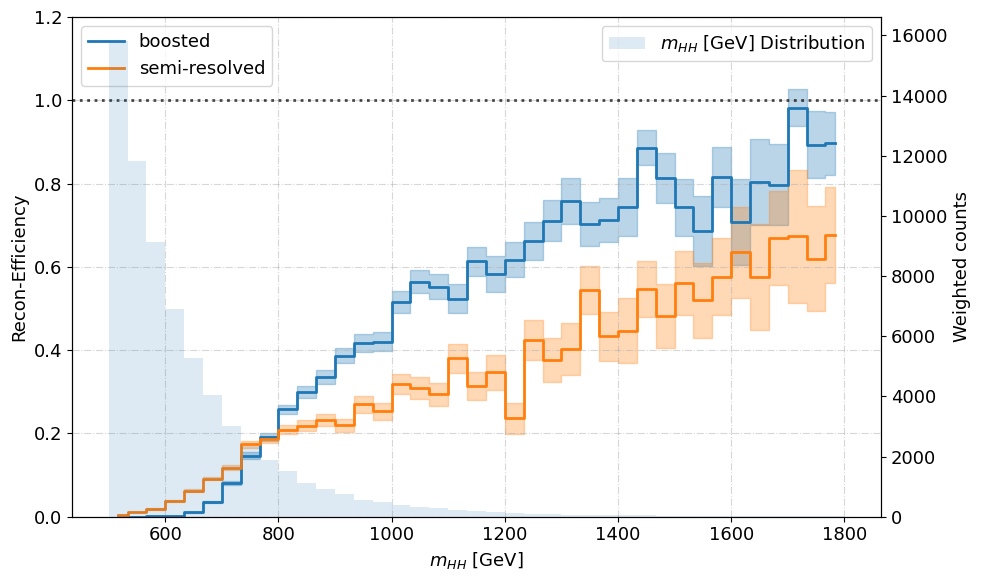

/tmp/ipykernel_549346/2470756934.py:36: RuntimeWarning: invalid value encountered in sqrt
  err = np.sqrt(eff * (1.0 - eff) / (1e-6 + neff), where=neff >= 0)


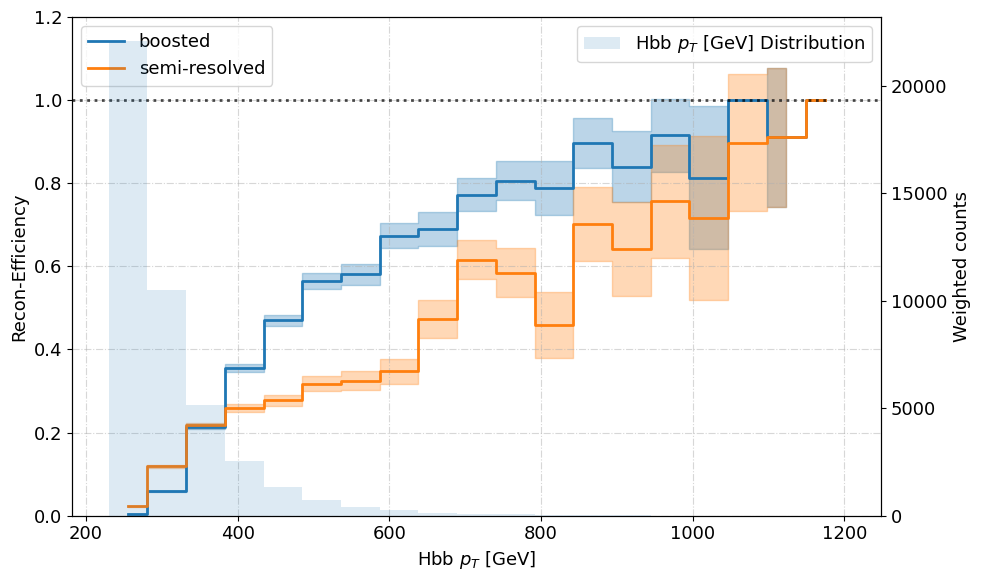

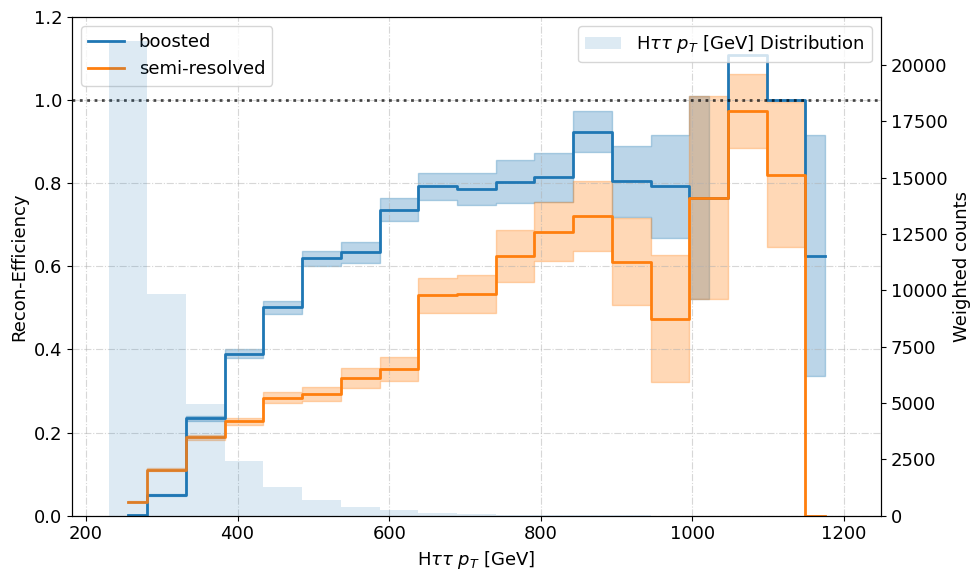

In [17]:
# (VOI) Variables Of Interest
weights = df_check["weight"][0]
higgs = utils.make_vector(df_check, name="GenHiggs")
mhh = (higgs[:, 0] + higgs[:, 1]).mass
hbbpt = higgs[df_check["GenHiggsChildren"] == 5].pt
httpt = higgs[df_check["GenHiggsChildren"] == 15].pt

plt.rcParams.update({'font.size':13})

plot_vars = [
    (mhh, "mhh", r"$m_{HH}$ [GeV]", np.linspace(500, 1800, 40)),
    (hbbpt, "hbbpt", r"Hbb $p_{T}$ [GeV]", np.linspace(230, 1200, 20)),
    (httpt, "httpt", r"H$\tau\tau$ $p_{T}$ [GeV]", np.linspace(230, 1200, 20)),
]


for kinvar, kinname, kinlabel, bins in plot_vars:
    eff_b, err_b, tot_b, _ = efficiency_vs(
        kinvar, recon_truth_dict['boosted'],
        bins, weights
    )
    eff_s, err_s, _, _ = efficiency_vs(
        kinvar, recon_truth_dict['semi'],
        bins, weights
    )

    bc = 0.5 * (bins[1:] + bins[:-1])
    width = np.diff(bins)

    fig, ax = plt.subplots(figsize=(10, 6))

    # Boosted: step + fill
    ax.step(bc, eff_b, where='mid', lw=2,
            label='boosted', color=colors['boosted'])
    ax.fill_between(
        bc, eff_b - err_b, eff_b + err_b,
        step='mid', alpha=0.3,
        color=colors['boosted']
    )

    # Semi-resolved: step + fill
    ax.step(bc, eff_s, where='mid', lw=2,
            label='semi-resolved', color=colors['semi'])
    ax.fill_between(
        bc, eff_s - err_s, eff_s + err_s,
        step='mid', alpha=0.3,
        color=colors['semi']
    )

    ax.set(xlabel=kinlabel, ylabel='Recon-Efficiency',
           ylim=(0, 1.2))
    ax.axhline(y=1, linestyle=':', color='black',
               alpha=0.7, linewidth=2)
    ax.grid(ls='-.', alpha=.5)

    ax2 = ax.twinx()
    ax2.bar(bc, tot_b, width=width,
            alpha=0.15, label=kinlabel + ' Distribution')
    ax2.set_ylabel('Weighted counts')

    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

In [18]:
def yields_vs(var, reco_mask, bins, weights=None):
    if weights is None:
        weights = np.ones_like(var)
    y, _ = np.histogram(var[reco_mask], bins=bins,
                        weights=weights[reco_mask])
    w2, _ = np.histogram(var[reco_mask], bins=bins,
                         weights=weights[reco_mask] ** 2)
    err = np.sqrt(w2)
    return y, err

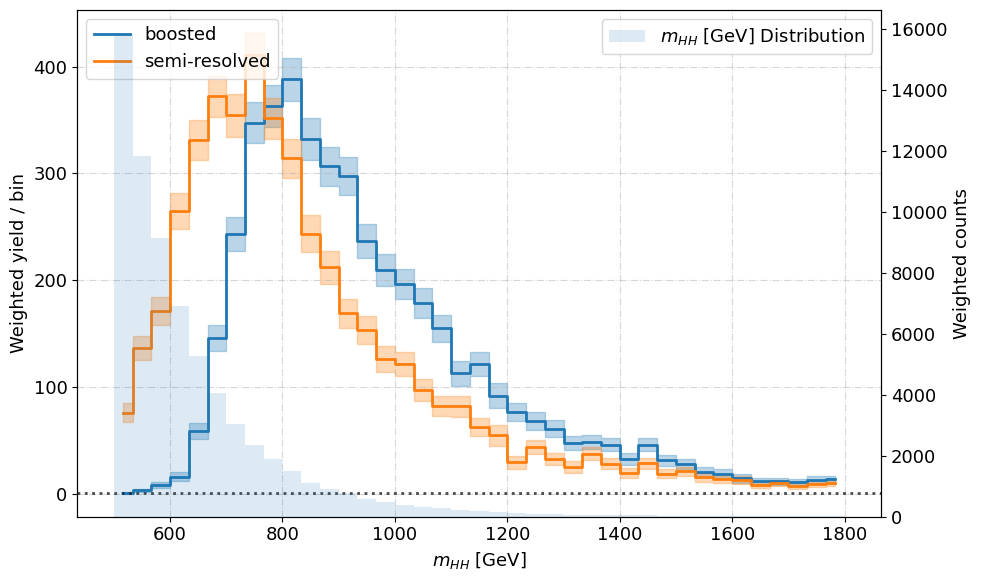

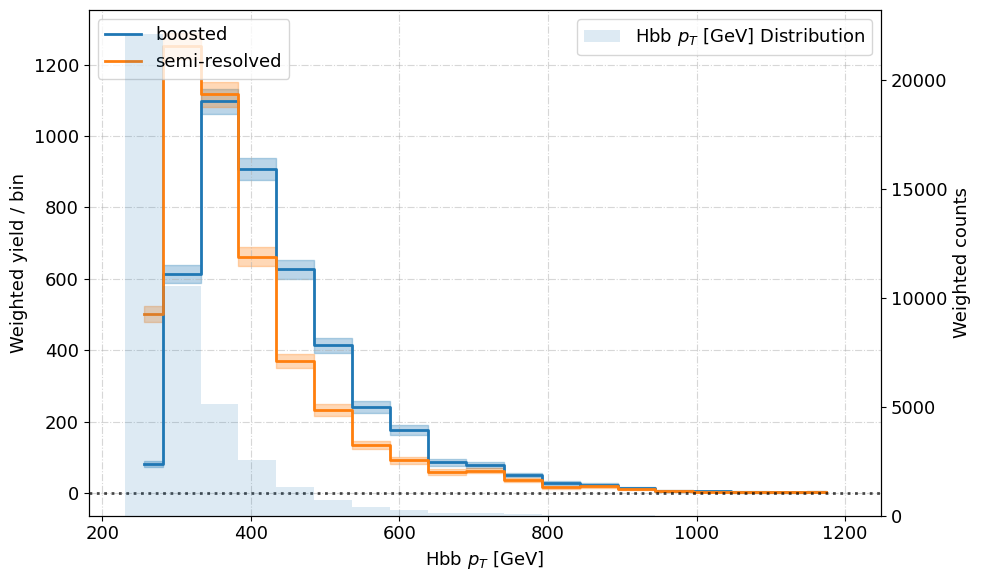

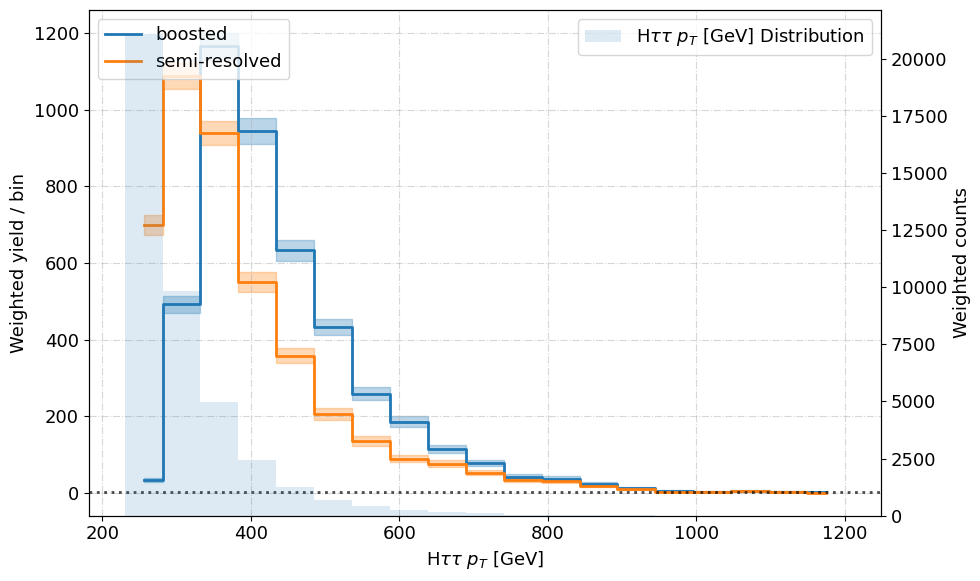

In [19]:
for kinvar, kinname, kinlabel, bins in plot_vars:
    reco_b, _ = recon_truth_dict['boosted']
    reco_s, _ = recon_truth_dict['semi']

    # Yields and statistical errors
    y_b, err_b = yields_vs(kinvar, reco_b, bins, weights)
    y_s, err_s = yields_vs(kinvar, reco_s, bins, weights)

    # Total distribution (background)
    tot_b, _ = np.histogram(kinvar, bins=bins, weights=weights)

    bc = 0.5 * (bins[1:] + bins[:-1])
    width = np.diff(bins)

    fig, ax = plt.subplots(figsize=(10, 6))

    # Boosted: step + error band
    ax.step(bc, y_b, where='mid', lw=2,
            label='boosted', color=colors['boosted'])
    ax.fill_between(
        bc, y_b - err_b, y_b + err_b,
        step='mid', alpha=0.3,
        color=colors['boosted']
    )

    # Semi-resolved: step + error band
    ax.step(bc, y_s, where='mid', lw=2,
            label='semi-resolved', color=colors['semi'])
    ax.fill_between(
        bc, y_s - err_s, y_s + err_s,
        step='mid', alpha=0.3,
        color=colors['semi']
    )

    # Optional horizontal line for visual aid
    ax.axhline(y=1, linestyle=':', color='black',
               alpha=0.7, linewidth=2)

    ax.set(xlabel=kinlabel, ylabel='Weighted yield / bin')
    ax.grid(ls='-.', alpha=0.5)

    # Twin axis for background distribution
    ax2 = ax.twinx()
    ax2.bar(bc, tot_b, width=width,
            alpha=0.15, label=kinlabel + ' Distribution')
    ax2.set_ylabel('Weighted counts')

    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


In [20]:
# df_sel = df_acc[sel_any_pass]
# df_check = df_sel

# boosted_reco = boosted_pass[sel_any_pass]
# boosted_gen  = gen_boosted_pass[sel_any_pass]
# semi_reco    = semi_pass[sel_any_pass]
# semi_gen     = gen_semi_pass[sel_any_pass]


In [21]:
print(f'bb -> Ak8 matched (bb_ak8): {weights[boosted_bb_pass].sum():.3f}')
print(f'ττ -> Ak8 matched (ττ_ak8): {weights[boosted_tautau_pass].sum():.3f}')
print(f'τ1-> Ak4_i AND τ2-> Ak4_j (i≠j) matched (ττ_ak4): {weights[is_2tautauak4].sum():.3f}')

recon_truth_dict = {
    'bb_ak8' : (boosted_bb_pass, None),
    'ττ_ak8' : (boosted_tautau_pass, None),
    'ττ_ak4' : (is_2tautauak4, None),

}

labels = {
    'bb_ak8': 'bb_ak8',
    'ττ_ak8': 'ττ_ak8',
    'ττ_ak4': 'ττ_ak4'
}

colors = {
    'bb_ak8': 'C2',
    'ττ_ak8': 'C3',
    'ττ_ak4': 'C4'
}

bb -> Ak8 matched (bb_ak8): 16540.489
ττ -> Ak8 matched (ττ_ak8): 6946.158
τ1-> Ak4_i AND τ2-> Ak4_j (i≠j) matched (ττ_ak4): 60427.628


/tmp/ipykernel_549346/2470756934.py:36: RuntimeWarning: invalid value encountered in sqrt
  err = np.sqrt(eff * (1.0 - eff) / (1e-6 + neff), where=neff >= 0)


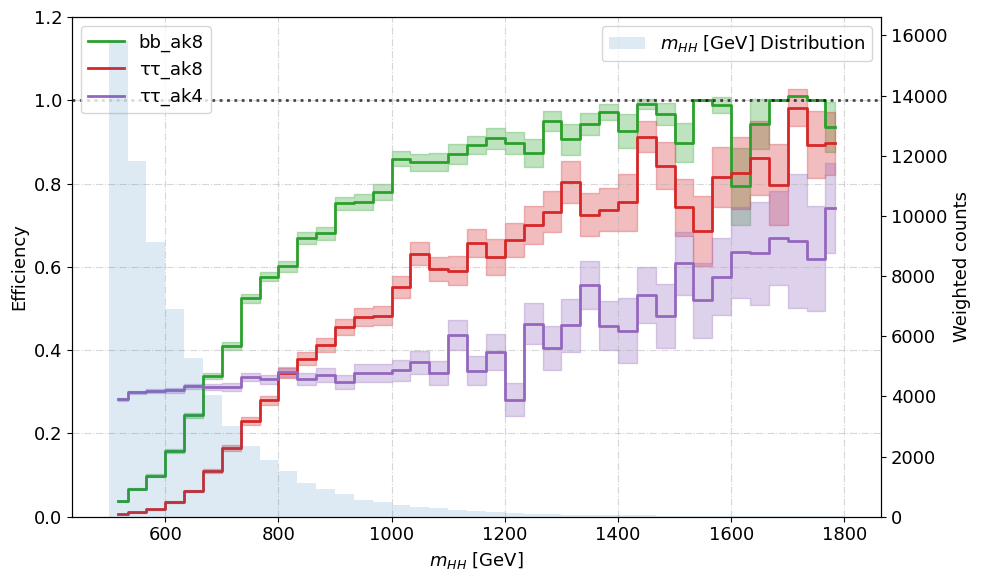

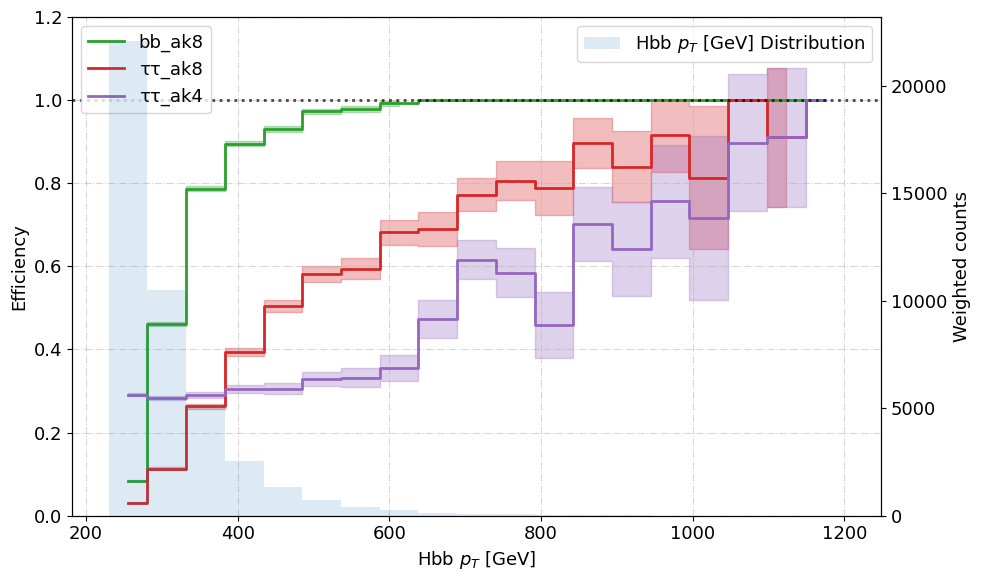

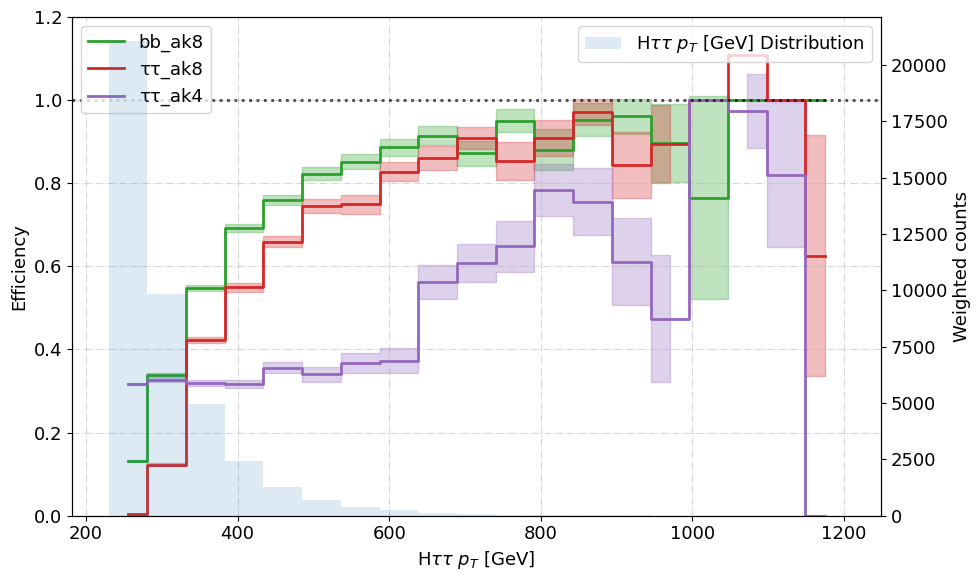

In [22]:
# (VOI) Variables Of Interest
weights = df_check["weight"][0]
higgs = utils.make_vector(df_check, name="GenHiggs")
mhh = (higgs[:, 0] + higgs[:, 1]).mass
hbbpt = higgs[df_check["GenHiggsChildren"] == 5].pt
httpt = higgs[df_check["GenHiggsChildren"] == 15].pt

plt.rcParams.update({'font.size':13})

plot_vars = [
    (mhh, "mhh", r"$m_{HH}$ [GeV]", np.linspace(500, 1800, 40)),
    (hbbpt, "hbbpt", r"Hbb $p_{T}$ [GeV]", np.linspace(230, 1200, 20)),
    (httpt, "httpt", r"H$\tau\tau$ $p_{T}$ [GeV]", np.linspace(230, 1200, 20)),
]


for kinvar, kinname, kinlabel, bins in plot_vars:
    bc = 0.5 * (bins[1:] + bins[:-1])
    width = np.diff(bins)

    fig, ax = plt.subplots(figsize=(10, 6))

    for key in ['bb_ak8', 'ττ_ak8', 'ττ_ak4']:
        reco_mask, _ = recon_truth_dict[key]
        eff, err, tot, _ = efficiency_vs(kinvar, (reco_mask, reco_mask),
                                         bins, weights)

        ax.step(bc, eff, where='mid', lw=2, label=labels[key],
                color=colors[key])
        ax.fill_between(bc, eff - err, eff + err, step='mid', alpha=0.3,
                        color=colors[key])

    ax.set(xlabel=kinlabel, ylabel='Efficiency', ylim=(0, 1.2))
    ax.axhline(y=1, linestyle=':', color='black', alpha=0.7, linewidth=2)
    ax.grid(ls='-.', alpha=.5)

    ax2 = ax.twinx()
    ax2.bar(bc, tot, width=width, alpha=0.15,
            label=kinlabel + ' Distribution')
    ax2.set_ylabel('Weighted counts')

    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


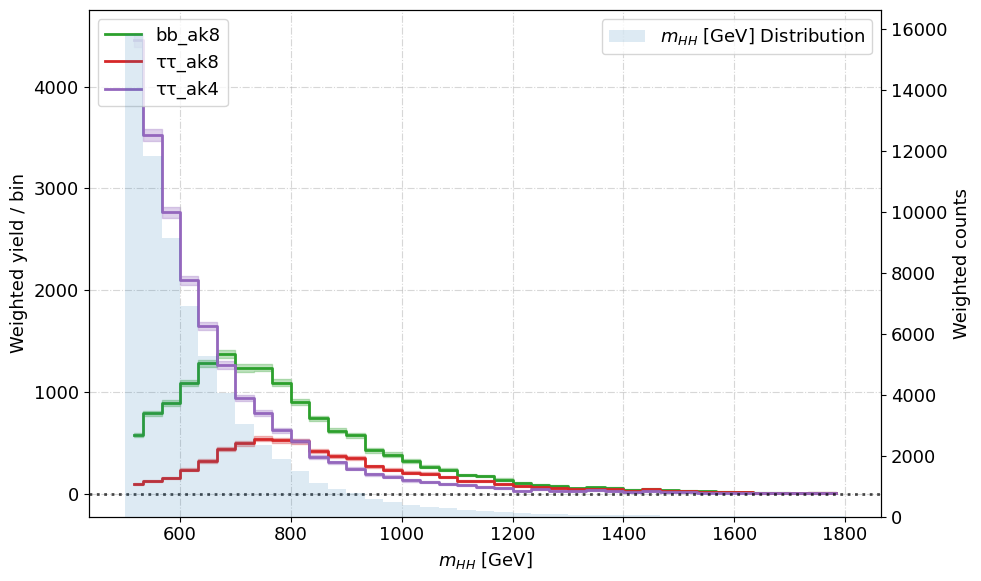

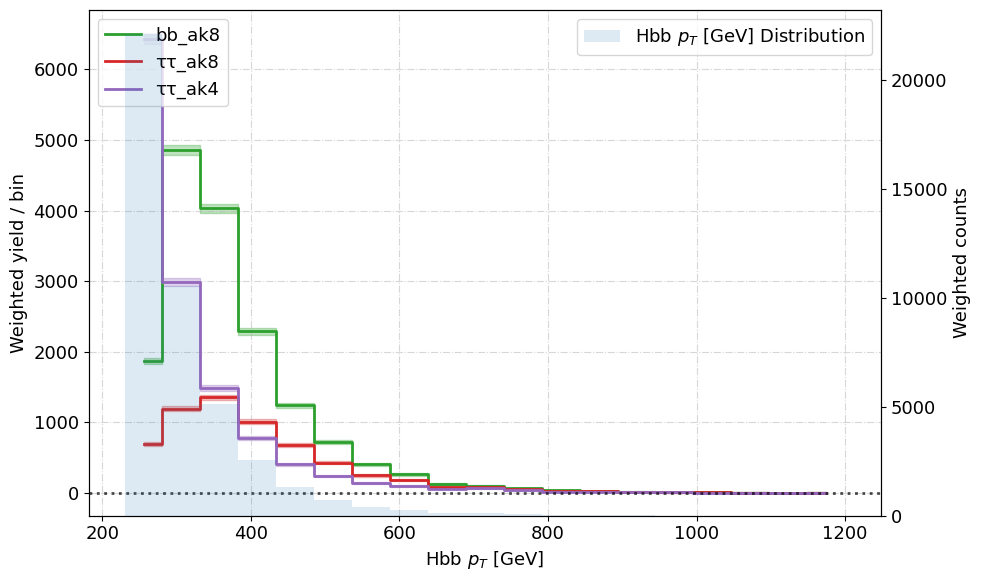

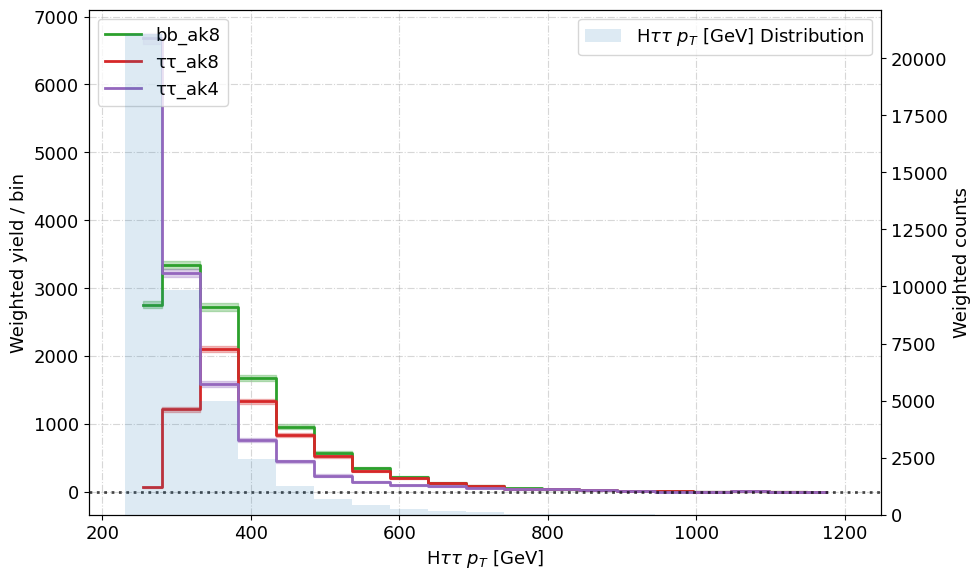

In [23]:
for kinvar, kinname, kinlabel, bins in plot_vars:
    bc = 0.5 * (bins[1:] + bins[:-1])
    width = np.diff(bins)

    fig, ax = plt.subplots(figsize=(10, 6))

    # background distribution (total selected)
    tot, _ = np.histogram(kinvar, bins=bins, weights=weights)

    for key in ['bb_ak8', 'ττ_ak8', 'ττ_ak4']:
        reco_mask, _ = recon_truth_dict[key]
        y, err = yields_vs(kinvar, reco_mask, bins, weights)

        ax.step(bc, y, where='mid', lw=2,
                label=labels[key], color=colors[key])
        ax.fill_between(bc, y - err, y + err,
                        step='mid', alpha=0.3,
                        color=colors[key])

    ax.set(xlabel=kinlabel, ylabel='Weighted yield / bin')
    ax.axhline(y=1, linestyle=':', color='black', alpha=0.7, linewidth=2)
    ax.grid(ls='-.', alpha=.5)

    # overlay total distribution in the background
    ax2 = ax.twinx()
    ax2.bar(bc, tot, width=width, alpha=0.15,
            label=kinlabel + ' Distribution')
    ax2.set_ylabel('Weighted counts')

    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


In [24]:
print('Reconstructed (Yields)')
print(f'bb -> Ak8 matched (bb_ak8): {weights[boosted_bb_pass].sum():.3f}')
print(f'ττ -> Ak8 matched (ττ_ak8): {weights[boosted_tautau_pass].sum():.3f}')
print(f'τ1-> Ak4_i AND τ2-> Ak4_j (i≠j) matched (ττ_ak4): {weights[is_2tautauak4].sum():.3f}')
print()
print(f'ττ_ak8 OR ττ_ak4: {weights[boosted_tautau_pass | is_2tautauak4].sum():.3f}')
N1 = weights[boosted_bb_pass & boosted_tautau_pass].sum()
N2 = weights[boosted_bb_pass & is_2tautauak4].sum()
print(f'bb_ak8 AND ττ_ak8 (N1): {N1:.3f}')
print(f'bb_ak8 AND ττ_ak4 (N2): {N2:.3f}')
print()
print(f'N1 + N2: {N1 + N2:.3f}')
N_R = weights[ boosted_bb_pass & (boosted_tautau_pass | is_2tautauak4)].sum()
print(f'(bb_ak8) AND (ττ_ak8 OR ττ_ak4) (N_R): {N_R:.3f}')
print()
print(f'Eps_reco = N_R/N_A: {N_R/N_A:.6f}')
print(f'Eps_1 = N1/N_R: {N1/N_R:.6f}')
print(f'Eps_2 = N2/N_R: {N2/N_R:.6f}')

print()
print(f'boosted (yield): {weights[boosted_pass].sum():.3f}')
print(f'semi (yield): {weights[semi_pass].sum():.3f}')
print(f'Total reconstructed (boosted + semi): {weights[boosted_pass | semi_pass].sum():.3f}')

Reconstructed (Yields)
bb -> Ak8 matched (bb_ak8): 16540.489
ττ -> Ak8 matched (ττ_ak8): 6946.158
τ1-> Ak4_i AND τ2-> Ak4_j (i≠j) matched (ττ_ak4): 60427.628

ττ_ak8 OR ττ_ak4: 63976.896
bb_ak8 AND ττ_ak8 (N1): 4477.106
bb_ak8 AND ττ_ak4 (N2): 4706.890

N1 + N2: 9183.996
(bb_ak8) AND (ττ_ak8 OR ττ_ak4) (N_R): 6946.170

Eps_reco = N_R/N_A: 0.033374
Eps_1 = N1/N_R: 0.644543
Eps_2 = N2/N_R: 0.677624

boosted (yield): 4477.106
semi (yield): 4706.890
Total reconstructed (boosted + semi): 6946.170


In [ ]:
# # ───────────── Selection cuts on reco AK8 / AK4 ─────────────
# sel_pt8 , sel_eta8 = acc_cond['pt_ak8'] , acc_cond['eta_ak8']
# sel_pt4 , sel_eta4 = acc_cond['pt_ak4'] , acc_cond['eta_ak4']

# good_ak8 = (ak8_pt  > sel_pt8)  & (np.abs(ak8_eta) < sel_eta8)
# good_ak4 = (ak4_pt  > sel_pt4)  & (np.abs(ak4_eta) < sel_eta4)

# # tie pT/η requirement to the original matching masks
# b_in_good8   = b_ak8_mask  &  good_ak8[..., None]
# tau_in_good8 = tau_ak8_mask & good_ak8[..., None]
# tau_in_good4 = tau_ak4_mask & good_ak4[..., None]

# sel_boosted_bb   = b_in_good8.all(axis=2).any(axis=1)
# sel_boosted_tt   = tau_in_good8.all(axis=2).any(axis=1)
# sel_two_good4    = tau_in_good4.any(axis=1).all(axis=1)

# boosted_sel_pass = sel_boosted_bb & sel_boosted_tt
# semi_sel_pass    = sel_boosted_bb & sel_two_good4
# sel_any_pass     = boosted_sel_pass | semi_sel_pass

# weights_sel  = weights[sel_any_pass]
# N_sel        = weights_sel.sum()
# eps_sel      = N_sel / N_R      # N_R from your matching block

# print('\nSelection (analysis) Yields')
# print(f'boosted_sel: {weights[boosted_sel_pass].sum():.3f}')
# print(f'semi_sel   : {weights[semi_sel_pass].sum():.3f}')
# print(f'total_sel  : {N_sel:.3f}')
# print(f'Eps_sel = N_sel / N_R : {eps_sel:.6f}')
